# Ejercicio 6 - Parquet versus tablas DuckDB

**Estrategias comparadas**

- **Parquet directo (6.1):** `trips_clean` es una vista sobre `read_parquet(...)`; cada consulta lee los archivos.
- **Tabla materializada (6.2):** `CREATE TABLE tbl_N AS SELECT * FROM trips_clean` en `data/processed/lab8.duckdb`.

Ambas se construyen con **la misma definicion de limpieza**, por lo que las consultas `sql/06_q*.sql` (con el marcador `{SRC}`)
son *identicas* y solo cambia el origen. Todo lo ejecuta `scripts/benchmark.py`:

```bash
python scripts/benchmark.py --repeticiones 5
```

Para cada alcance (1 mes, 1, 2 y 3 anios; 6.6) y cada consulta se miden 5 repeticiones; se reporta la **primera** y la **mediana**
(`docs/benchmark_results.csv`). Nota: los archivos ya estaban en la cache del sistema operativo tras la descarga/limpieza, por lo que
la primera ejecucion no es una lectura "fria" de disco; el contraste cold/warm de Parquet se aprecia sobre todo en el alcance mas grande.

## 6.3 y 6.8 Consultas del benchmark

In [1]:
import sys; sys.path.insert(0, "../scripts")
import labutil as lu
for n in ["06_q1_overall", "06_q2_monthly", "06_q3_hourly", "06_q4_selective", "06_q5_heavy"]:
    print((lu.SQL_DIR / f"{n}.sql").read_text())

-- Q1 agregacion global: tarifa y distancia medias por taxi (escanea pocas columnas).
SELECT taxi, count(*) AS viajes, avg(fare_amount) AS tarifa_media, avg(trip_distance) AS dist_media
FROM {SRC} GROUP BY taxi;

-- Q2 serie mensual: viajes por anio, mes y taxi.
SELECT data_year, data_month, taxi, count(*) AS viajes
FROM {SRC} GROUP BY ALL ORDER BY ALL;

-- Q3 perfil horario: viajes y propina media por hora y medio de pago.
SELECT hour(pickup) AS hora, payment_type, count(*) AS viajes, avg(tip_amount) AS propina_media
FROM {SRC} GROUP BY ALL ORDER BY ALL;

-- Q4 filtro selectivo: una semana de enero de 2026 (candidato a predicate pushdown).
SELECT taxi, count(*) AS viajes, sum(total_amount) AS ingresos
FROM {SRC}
WHERE pickup >= TIMESTAMP '2026-01-10' AND pickup < TIMESTAMP '2026-01-17'
GROUP BY taxi;

-- Q5 agregacion pesada: 20 pares origen-destino mas frecuentes con percentiles (alta cardinalidad).
SELECT pu_location, do_location, count(*) AS viajes, avg(fare_amount) AS tarifa_media

| Id | Tipo de carga | Que mide |
|----|---------------|----------|
| Q1 | agregacion global, 4 columnas | escaneo completo con pocas columnas |
| Q2 | serie mensual | agrupacion por `data_year`/`data_month` (derivadas del nombre de archivo) |
| Q3 | perfil horario x pago | funcion sobre timestamp + 2 claves de grupo |
| Q4 | filtro selectivo (1 semana) | *predicate pushdown* y estadisticas de row groups |
| Q5 | pares origen-destino + percentil | agrupacion de alta cardinalidad (~40 mil grupos) |

## 6.5-6.7 Resultados (tiempos en segundos; mediana de 5 repeticiones)

In [2]:
import pandas as pd, matplotlib.pyplot as plt
res = pd.read_csv("../docs/benchmark_results.csv")
q = res[res.consulta != "CREATE TABLE"]
tab = q.pivot_table(index=["alcance", "filas"], columns=["consulta", "fuente"], values="mediana_s").sort_index(level="filas")
tab.round(3)

consulta                           06_q1_overall        06_q2_monthly         \
fuente                                   parquet  tabla       parquet  tabla   
alcance                  filas                                                 
1 mes (2026-01)          3553835           0.083  0.007         0.074  0.007   
1 anio (2026)            28539846          0.379  0.051         0.324  0.044   
2 anios (2025+2026)      73253392          1.002  0.125         0.889  0.104   
3 anios (2024+2025+2026) 113555207         1.407  0.195         1.237  0.156   

consulta                           06_q3_hourly        06_q4_selective         \
fuente                                  parquet  tabla         parquet  tabla   
alcance                  filas                                                  
1 mes (2026-01)          3553835          0.090  0.006           0.049  0.002   
1 anio (2026)            28539846         0.398  0.061           0.058  0.002   
2 anios (2025+2026)      73253392         1.037  0.133           0.065  0.002   
3 anios (2024+2025+2026) 113555207        1.589  0.190           0.115  0.003   

consulta                           06_q5_heavy         
fuente                                 parquet  tabla  
alcance                  filas                         
1 mes (2026-01)          3553835         0.132  0.040  
1 anio (2026)            28539846        0.640  0.280  
2 anios (2025+2026)      73253392        1.633  0.607  
3 anios (2024+2025+2026) 113555207       2.733  0.867

In [3]:
ratio = q.pivot_table(index=["alcance", "filas"], columns=["consulta", "fuente"], values="mediana_s")
speedup = pd.DataFrame({c: ratio[(c, "parquet")] / ratio[(c, "tabla")] for c in q.consulta.unique()}).sort_index(level="filas")
print("Veces que la tabla es mas rapida que Parquet (mediana):")
speedup.round(1)

Veces que la tabla es mas rapida que Parquet (mediana):


,,06_q1_overall,06_q2_monthly,06_q3_hourly,06_q4_selective,06_q5_heavy
alcance,filas,,,,,
1 mes (2026-01),3553835,12.3,10.8,13.8,21.2,3.3
1 anio (2026),28539846,7.5,7.5,6.5,24.0,2.3
2 anios (2025+2026),73253392,8.0,8.5,7.8,25.8,2.7
3 anios (2024+2025+2026),113555207,7.2,7.9,8.3,37.1,3.2


In [4]:
crear = res[res.consulta == "CREATE TABLE"].set_index("alcance")[["filas", "mediana_s"]].rename(columns={"mediana_s": "crear_tabla_s"})
crear.sort_values("filas")

,filas,crear_tabla_s
alcance,,
1 mes (2026-01),3553835,0.8807
1 anio (2026),28539846,4.1441
2 anios (2025+2026),73253392,10.7303
3 anios (2024+2025+2026),113555207,14.8601


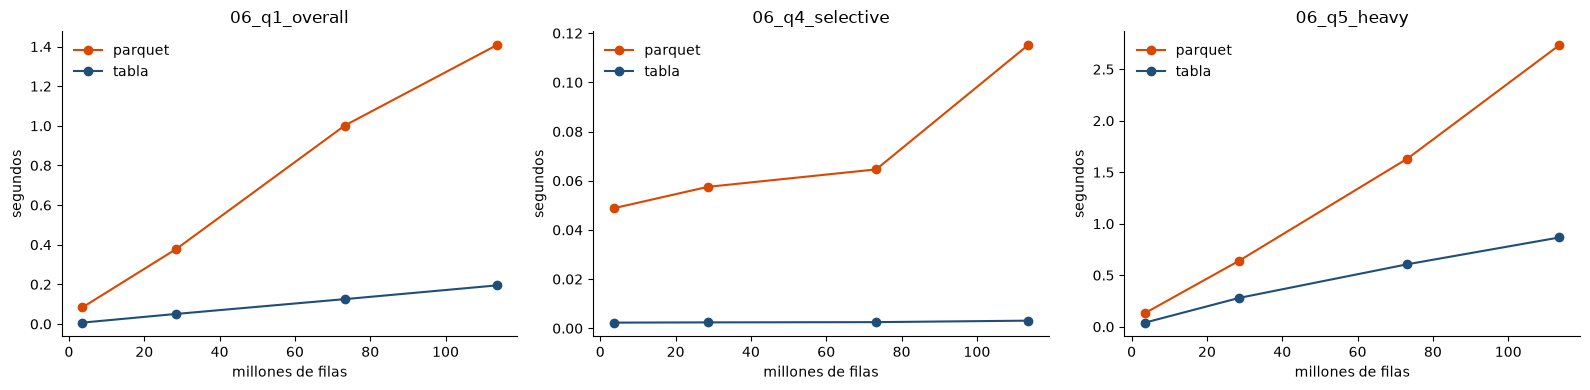

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axs, ["06_q1_overall", "06_q4_selective", "06_q5_heavy"]):
    for fuente, color in [("parquet", "#d94801"), ("tabla", "#1f4e79")]:
        g = q[(q.consulta == c) & (q.fuente == fuente)].sort_values("filas")
        ax.plot(g.filas / 1e6, g.mediana_s, marker="o", color=color, label=fuente)
    ax.set(title=c, xlabel="millones de filas", ylabel="segundos"); ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Verificacion de equivalencia y punto de equilibrio

In [6]:
# Ambos origenes devuelven lo mismo? (Q2 sobre el alcance de 3 anios)
con_pq = lu.connect()
con_tb = lu.connect(str(lu.PROCESSED / "lab8.duckdb"), read_only=True, views=False)
tablas = con_tb.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY estimated_size DESC").fetchall()
mayor = tablas[0][0]
a = con_pq.execute(lu.sql_text("06_q2_monthly.sql", SRC="trips_clean")).df()
b = con_tb.execute(lu.sql_text("06_q2_monthly.sql", SRC=mayor)).df()
print("tablas:", tablas); print("resultados identicos:", a.equals(b))

tablas: [('tbl_3', 113555207), ('tbl_2', 73253392), ('tbl_1', 28539846), ('tbl_0', 3553835)]
resultados identicos: True


In [7]:
import numpy as np
g = res[res.alcance.str.startswith("3")]
ahorro = (g[g.fuente == "parquet"].set_index("consulta").mediana_s - g[g.fuente == "tabla"].set_index("consulta").mediana_s).drop("CREATE TABLE", errors="ignore")
t_crear = float(g[g.consulta == "CREATE TABLE"].mediana_s.iloc[0])
print(f"Crear la tabla (3 anios): {t_crear:.1f} s. Ahorro medio por consulta: {ahorro.mean():.2f} s")
print(f"Punto de equilibrio: ~{t_crear / ahorro.mean():.0f} consultas del mismo tipo")
import os; print(f"Tamano de la base completa (4 tablas del benchmark): {os.path.getsize(lu.PROCESSED / 'lab8.duckdb') / 2**30:.1f} GiB")

Crear la tabla (3 anios): 14.9 s. Ahorro medio por consulta: 1.13 s
Punto de equilibrio: ~13 consultas del mismo tipo
Tamano de la base completa (4 tablas del benchmark): 5.7 GiB


## 6.9 Analisis de resultados

1. **La tabla gana en todos los casos**, entre ~2x (Q5) y ~12x (Q1 con 1 mes) en consultas de agregacion; y hasta ~37x en el filtro selectivo Q4.
   Una tabla DuckDB almacena columnas ya limpias, tipadas y comprimidas con sus propias estadisticas; ademas la limpieza (`trips_clean`,
   que incluye `regexp_extract` sobre el nombre de archivo y varios filtros) ya fue pagada una sola vez al materializar, mientras que con Parquet se repite en cada consulta.
2. **Parquet directo escala casi linealmente con los datos** (Q1: 0.08 s con 3.5 M filas -> 1.4 s con 113 M), igual que la tabla pero con una constante ~8x mayor.
   Aun asi, 1-3 segundos para 113 M de filas sin ninguna carga previa es notable.
3. **Q4 (filtro selectivo)** es el caso donde mas se nota la materializacion (37x), pero Parquet tambien lo resuelve rapidisimo (0.05-0.11 s) porque
   las estadisticas min/max de los row groups permiten saltar la mayor parte de los archivos y a que los datos vienen casi ordenados por tiempo.
4. **Q5 (alta cardinalidad)** reduce la ventaja (2-3x): el costo dominante es la agregacion hash y el calculo del percentil, no la lectura.
5. **Costo de materializar:** de 0.9 s (1 mes) a ~15 s (3 anios) y ~1 GB por cada anio de datos en disco (la base con los 4 alcances ocupa 5.7 GiB);
   con el ahorro medio medido (~1.1 s por consulta con 3 anios) se amortiza tras ~13 consultas.
6. **Primera vs mediana:** casi no difieren porque los Parquet ya estaban en la cache del sistema operativo; con datos que no caben en cache,
   la primera consulta Parquet seria mas lenta (lectura de disco), mientras que la tabla tambien debe leerse una vez.

## 6.10 Cuando usar cada estrategia

| Situacion | Recomendacion |
|-----------|---------------|
| Exploracion inicial, consultas ocasionales o unicas | **Parquet directo**: cero carga, sin duplicar disco. |
| Los archivos crecen continuamente (nuevos meses) | **Parquet directo** (o vistas): lo nuevo aparece solo al agregar archivos. |
| Pipelines que leen una vez (ETL, conversion) | **Parquet directo**. |
| Muchas consultas repetidas sobre el mismo conjunto (tableros, benchmarks, notebooks) | **Tabla materializada**: se amortiza en ~13 consultas con 3 anios. |
| Se requiere limpieza/transformacion costosa en cada consulta | **Tabla** (o una tabla/Parquet derivado de `trips_clean`). |
| Joins, indices, actualizaciones o consultas concurrentes tipo servicio | **Tabla**. |
| Poco disco disponible | **Parquet directo** (la tabla ocupa del orden de 1 GB por anio de datos). |

En este laboratorio la estrategia mixta es la adecuada: Parquet crudo como fuente de verdad y una tabla derivada para el tablero.